In [1]:
# Directories and module imports
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

from polarity.utilities.metric_functions import polarity_measure, find_interface
from polarity.utilities import figure_helper as fh

cycle_progression_dir = Path(fh.DATA_DIR / "cycle_sweeps_PAR3ND")
loss_sensitivity_dir = Path(fh.DATA_DIR / "sensitivity_MS_loss_PAR3ND")

## Fig. 7: Downregulation of $\rho_P$ and $\rho_A$ over secretory phase

In [2]:
# Data load and process

# Cycle sequence (proliferative, early secretory, mid sec., late sec.)
# From Whitby et al. (2017)
cycle_points = pd.DataFrame({
    "multiplier_rho_A": [1, 0.50, 0.50, 0.50],
    "multiplier_rho_P": [1, 0.75, 0.40, 0.15],
    "phase_label": ["P", "ES", "MS", "LS"]
})

# Parameters
param_i = "rho_A"
param_j = "rho_P"

# Read in the files from the folder
cycle_sensitivity_files = list(cycle_progression_dir.glob("*.pkl"))
cycle_sensitivity_results = []
for file in cycle_sensitivity_files:
    with open(file, 'rb') as f:
        res_list = pickle.load(f)
        cycle_sensitivity_results.extend(res_list)

# Get metrics as a data frame
cycle_metrics_df = pd.DataFrame(columns=[param_i, param_j, "polarity", "interface"])
for i, (sol, setup) in enumerate(cycle_sensitivity_results):
    polarity = polarity_measure(setup["X"], sol.y[:,-1], species = setup["Species"])
    interface = find_interface(setup["X"], sol.y[:,-1], species = setup["Species"])
    cycle_metrics_df.loc[i] = [setup[f"{param_i}_mult"], setup[f"{param_j}_mult"], polarity, interface]
print(cycle_metrics_df.head())

# Extract the data from the labelled cycle points
cycle_points_results = {}
multipliers_rhoA_list = [setup["rho_A_mult"] for _, setup in cycle_sensitivity_results]
multipliers_rhoP_list = [setup["rho_P_mult"] for _, setup in cycle_sensitivity_results]
for row in cycle_points.itertuples():
    ind = [i for i, (rho_A, rho_P) in enumerate(zip(multipliers_rhoA_list, multipliers_rhoP_list)) 
            if rho_A == row.multiplier_rho_A and rho_P == row.multiplier_rho_P]
    assert len(ind) == 1, f"Expected one match for {row.phase_label}, found {len(ind)}"
    cycle_points_results[row.phase_label] = cycle_sensitivity_results[ind[0]]

   rho_A  rho_P  polarity  interface
0    1.3  0.100 -0.000102        0.0
1    1.3  0.125 -0.000102        0.0
2    1.3  0.150 -0.000102        0.0
3    1.3  0.175 -0.000102        0.0
4    1.3  0.200 -0.000102        0.0


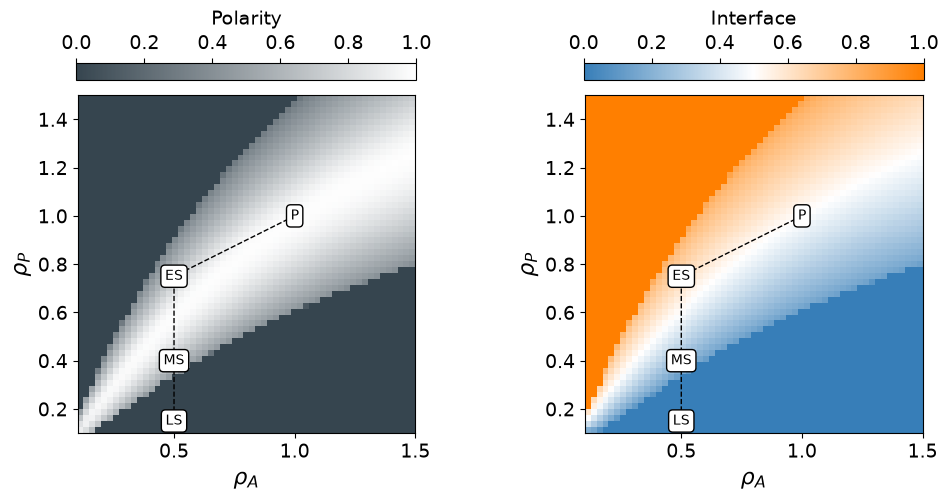

In [3]:
# Plot the heatmaps
fig, axs = plt.subplots(1, 2, figsize=(fh.page_width_fig, 0.4*fh.page_width_fig))
for ax, metric, cmap in zip(axs, ["polarity", "interface"], [fh.cmap_polarity, fh.cmap_interface]):
    # For heatmap: index = y value (=j), columns = x values (=i), values = z value
    heatmap_data = cycle_metrics_df.pivot(index=param_j, columns=param_i, values=metric)
    x_range = [np.min(heatmap_data.columns.values), np.max(heatmap_data.columns.values)]
    y_range = [np.min(heatmap_data.index.values), np.max(heatmap_data.index.values)]
    im = ax.imshow(heatmap_data, cmap=cmap, vmin = 0, vmax = 1, extent=[x_range[0], x_range[1], y_range[0], y_range[1]], origin='lower')

    ax.set_xlabel(fh.format_param_label_math(param_i))
    ax.set_ylabel(fh.format_param_label_math(param_j))

    # Create colorbar
    cbar = ax.figure.colorbar(im, ax=ax, orientation='horizontal', location = "top",fraction=0.046, pad=0.04)
    cbar.ax.set_title(metric.capitalize(), fontsize = fh.label_font_size, pad=7)

    # Add the labels at the points in cycle_points
    ax.plot(cycle_points[f"multiplier_{param_i}"], cycle_points[f"multiplier_{param_j}"], '--k', linewidth = 1)
    for i, row in cycle_points.iterrows():
        ax.text(row[f"multiplier_{param_i}"], row[f"multiplier_{param_j}"], row["phase_label"], 
                bbox=dict(boxstyle="round", facecolor='white', edgecolor='black'), 
                fontsize = 10, ha='center', va='center')
        
fig.savefig(fh.FIGURES_DIR / "cycle_variation_heatmaps.pdf")

Polarity for P: 0.989
Polarity for ES: 0.702
Polarity for MS: 0.690
Polarity for LS: -0.000


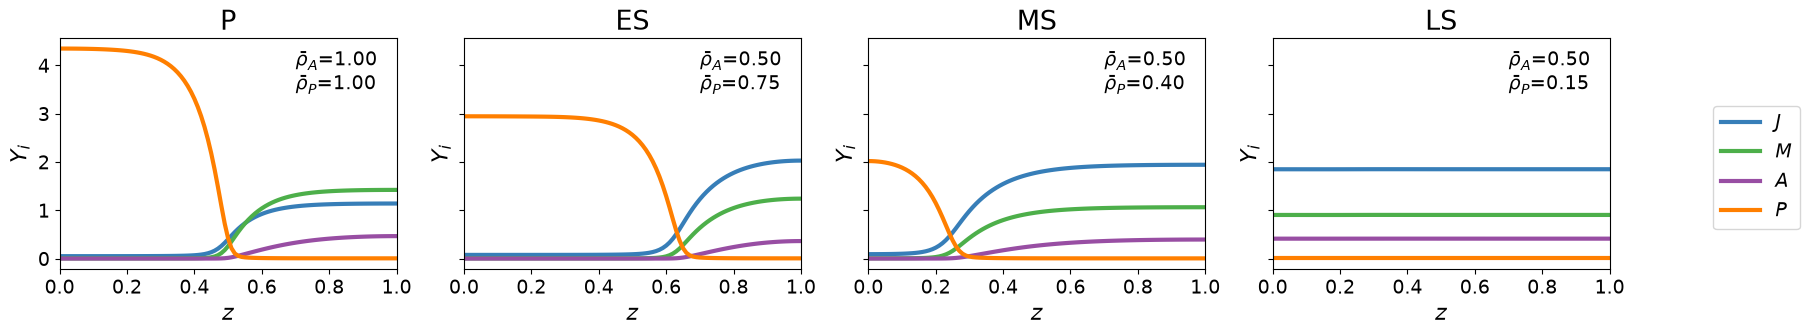

In [4]:
# Plot the final timepoint for each phase
fig, axs = plt.subplots(1,4, sharey=True)
fig.set_size_inches(20,3)
for ax, (phase, res) in zip(axs,cycle_points_results.items()):
    sol, setup = res
    polarity = polarity_measure(setup["X"], sol.y[:,-1], species = setup["Species"])
    fh.plot_time_point(ax, setup["X"], sol.y[:,-1])
    # ax.set_title(f"{phase} ($\\phi$={polarity:.2f})")
    ax.set_title(phase)
    label = f"$\\bar\\rho_A$={setup['rho_A_mult']:.2f}\n$\\bar\\rho_P$={setup['rho_P_mult']:.2f}"
    ax.text(0.7, 3.5, label, fontsize = 14)
    # Also print the level of polarity for reference
    print(f"Polarity for {phase}: {polarity:.3f}")
fh.add_shared_legend(fig, axs)
fig.savefig(fh.FIGURES_DIR / "cycle_variation_profiles.pdf", bbox_inches='tight')

In [14]:
# Peak values for each species and phase
print(f"Peak values:")
for (phase, res) in cycle_points_results.items():
    sol, setup = res
    df = fh.convert_output_to_pandas(setup["X"], sol.y[:,-1], setup["Species"])
    print(f"{phase}: ", ", ".join([f"{col}={val:.3f}" for col, val in df.max(axis=0).items() if col in setup["Species"]]))

Peak values:
P:  J=1.139, M=1.421, A=0.464, P=4.347
ES:  J=2.027, M=1.240, A=0.362, P=2.945
MS:  J=1.941, M=1.062, A=0.394, P=2.018
LS:  J=1.849, M=0.904, A=0.412, P=0.002


## Fig. 8: Loss sensitivity

In [15]:
# Functions definitions (loading data and plotting heat maps)
def read_simulation_data(param_name):
    filename = loss_sensitivity_dir / f"{param_name}_sweep.pkl"
    with open(filename, "rb") as f:
        res_list = pickle.load(f)
    return res_list

def get_polarity_measures(param_name):
    res_list = read_simulation_data(param_name)
    df = pd.DataFrame(
        {"parameter": param_name,
        "multiplier": [setup[f"{param_name}_mult"] for res, setup in res_list],
        "polarity": [polarity_measure(setup["X"], res.y[:,-1], species = setup["Species"]) for res, setup in res_list],
        "interface": [find_interface(setup["X"], res.y[:,-1], species = setup["Species"]) for res, setup in res_list] }
    )
    return df

def plot_heatmap(ax, metrics_df, metric_name, cmap = "viridis"):
    # For heatmap: index = y value, columns = x values, values = z value
    heatmap_data = metrics_df.pivot(index="parameter", columns="multiplier", values=metric_name)

    hm = sns.heatmap(heatmap_data, cmap=cmap, ax=ax, vmin = 0, vmax = 1, xticklabels=20,
                     cbar_kws={'orientation': 'horizontal','location': 'top'})
    cbar = hm.collections[0].colorbar
    cbar.outline.set_visible(True)
    cbar.outline.set_edgecolor("black")
    cbar.outline.set_linewidth(1.0)
    cbar.ax.set_title(metric_name.capitalize(), pad=8, fontsize = fh.label_font_size)   # title above the bar

    ax.set_yticklabels([fh.format_param_label_math(lbl) for lbl in heatmap_data.index], rotation = 0)
    ax.set_xlabel("Scaling Coefficient, $\\alpha$")
    ax.set_ylabel("Parameter")
    ax.spines[:].set_visible(True)

### Mid-Secretory

In [16]:
# Read in all the parameter sweeps and concatenate into a single data frame
file_list = list(Path(loss_sensitivity_dir).glob("*.pkl"))
params = [f.stem.replace("_sweep", "") for f in file_list]
metrics = pd.concat([get_polarity_measures(param) for param in params], ignore_index=True)
# Order by minimum polarity value for each parameter
metrics = metrics.sort_values(by="polarity", ascending=True)

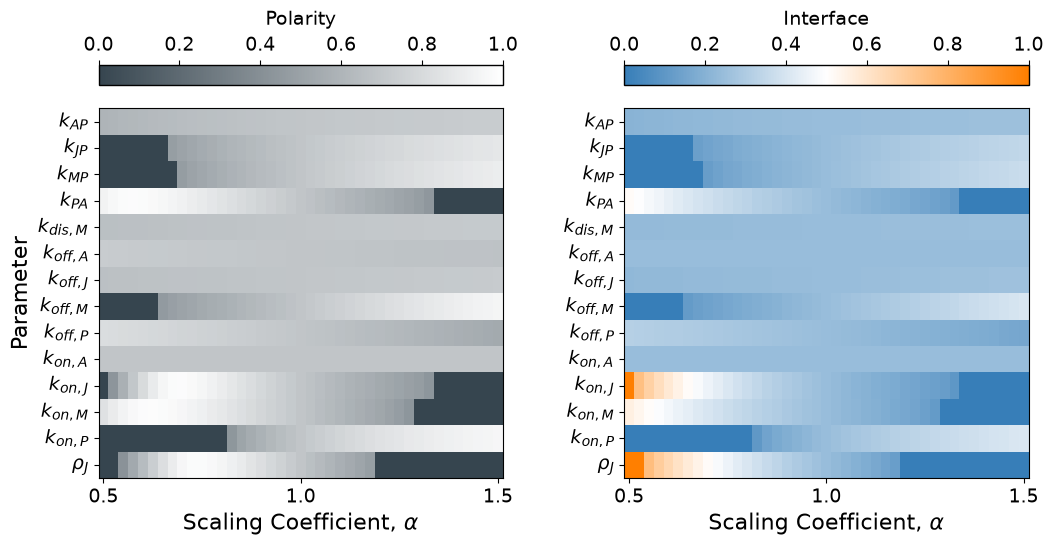

In [17]:
# Plot the heatmaps
fig, ax = plt.subplots(1, 2, figsize=(fh.page_width_fig, 6))
# Make the margines wider to accomodate the colorbar
plt.subplots_adjust(wspace=0.3)
# Heatmaps
plot_heatmap(ax[0], metrics, "polarity", cmap = fh.cmap_polarity)
plot_heatmap(ax[1], metrics, "interface", cmap = fh.cmap_interface)
_ = ax[1].set_ylabel(None)
fig.savefig(fh.FIGURES_DIR / "loss_sensitivity_heatmaps-MS.pdf")

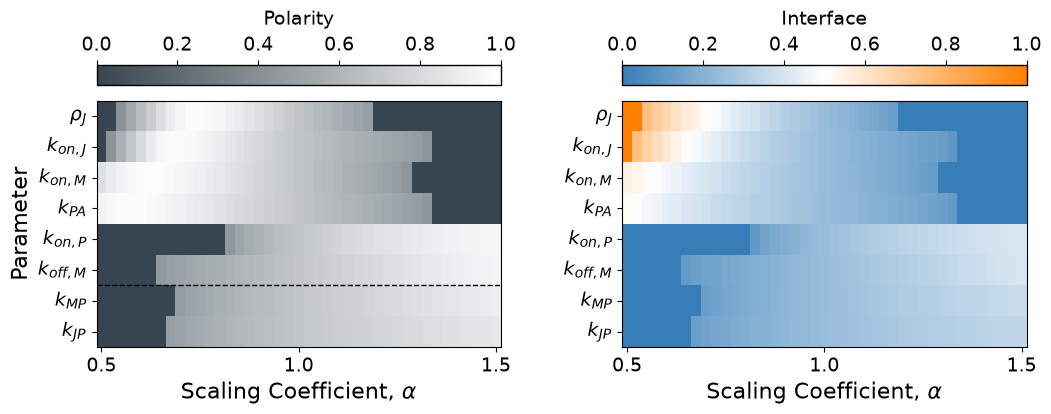

In [18]:
# Only plot parameters that have polarity values > epsilon
# Filter and sort the parameters
polarity_threshold = (0.1, 0.9)
filtered_metrics = metrics.groupby("parameter").filter(
    lambda x: min(x["polarity"]) < polarity_threshold[0] or max(x["polarity"]) > polarity_threshold[1])
parameter_order = filtered_metrics.groupby("parameter")["interface"].max().reset_index().sort_values(["interface", "parameter"], ascending=[False, False])["parameter"]
filtered_metrics["parameter"] = filtered_metrics["parameter"].astype("category")
filtered_metrics["parameter"] = filtered_metrics["parameter"].cat.reorder_categories(parameter_order, ordered = True)
filtered_metrics = filtered_metrics.sort_values(by=["parameter", "multiplier"])
# print(filtered_metrics.groupby("parameter")["polarity"].max().reset_index().sort_values("polarity", ascending=False))

fig, ax = plt.subplots(1, 2, figsize=(fh.page_width_fig, 4))
# Make the margines wider to accomodate the colorbar
plt.subplots_adjust(wspace=0.3)
# Heatmaps
plot_heatmap(ax[0], filtered_metrics, "polarity", cmap = fh.cmap_polarity)
plot_heatmap(ax[1], filtered_metrics, "interface", cmap = fh.cmap_interface)
ax[0].axhline(y = 6, color = "black", linestyle = "--", linewidth = 1)
_ = ax[1].set_ylabel(None)
fig.savefig(fh.FIGURES_DIR / "loss_sensitivity_heatmaps-MS-filtered.pdf")